In [21]:
#张量运算
import tensorflow as tf

print(tf.__version__)

#检查是否有GPU
print(tf.config.list_physical_devices('GPU'))

#声明常数
a = tf.constant([[1,2,3,4]])
print(a)
print(a + 10)
print(a - 10)
print(a / 10)
print(a * 10)

print(a.numpy())
print("===========================================\n")
#转为负数
print(tf.negative(a))
print("===========================================\n")

#做加法

#两个数
print(tf.add(1,2))
#两个向量相加
print(tf.add([1,2],[3,4]))

#平方
print(tf.square(5))
print(tf.square([1,2,3]))
print("=================计算和========================\n")
print(tf.reduce_sum([1,2,3]))
print(tf.reduce_sum(tf.constant([1,2,3])))
print(tf.reduce_sum([[1,2,5],[3,4,5]]))


2.18.0
[]
tf.Tensor([[1 2 3 4]], shape=(1, 4), dtype=int32)
tf.Tensor([[11 12 13 14]], shape=(1, 4), dtype=int32)
tf.Tensor([[-9 -8 -7 -6]], shape=(1, 4), dtype=int32)
tf.Tensor([[0.1 0.2 0.3 0.4]], shape=(1, 4), dtype=float64)
tf.Tensor([[10 20 30 40]], shape=(1, 4), dtype=int32)
[[1 2 3 4]]

tf.Tensor([[-1 -2 -3 -4]], shape=(1, 4), dtype=int32)

tf.Tensor(3, shape=(), dtype=int32)
tf.Tensor([4 6], shape=(2,), dtype=int32)
tf.Tensor(25, shape=(), dtype=int32)
tf.Tensor([1 4 9], shape=(3,), dtype=int32)
=================计算和========================

tf.Tensor(6, shape=(), dtype=int32)
tf.Tensor(6, shape=(), dtype=int32)
tf.Tensor(20, shape=(), dtype=int32)


In [4]:
#
import tensorflow as tf

'''
    tensorflow中的常数放在CPU上(使用constant方法),其他的放在GPU上
'''
x1 = tf.constant([1,2,3],dtype=tf.float32)
print("x1 是否在GPU #0 上:",x1.device.endswith('GPU:0')) # false,分配到cpu上

#设定x为均匀分配乱数 3x3
x2 = tf.random.uniform([3,3])
print("x2 是否在GPU #0 上:",x2.device.endswith('GPU:0')) # 如果有显卡,true

#
x3 = x1 + x2
print("x3 是否在GPU #0 上:",x3.device.endswith('GPU:0')) # 如果有显卡,true

x1 是否在GPU #0 上: False
x2 是否在GPU #0 上: False
x3 是否在GPU #0 上: False


In [34]:
#指定CPU或者GPU
import tensorflow as tf
import time

print(tf.config.list_physical_devices('CPU'))

#计算10次的时间
def time_matnul(x):
    start = time.time()
    for _ in range(10):
        tf.matmul(x,x)
    result = time.time() - start
    print("{:0.2f}ms".format(result*1000))

#强制在cpu上计算
print("在CPU上计算")
with tf.device("CPU:0"):
    x = tf.random.uniform([1000,1000])
    time_matnul(x)

#在GPU上计算
if tf.config.list_physical_devices('GPU'):
    print("在GPU上计算")
    with tf.device("GPU:0"):
        x = tf.random.uniform([1000,1000])
        time_matnul(x)


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
在CPU上计算
56.85ms


In [40]:
#稀疏矩阵(Sparser Matrix)
import tensorflow as tf
import numpy as np
'''
    1   0   0   0
    0   0   2   0
    0   0   0   0

'''
sparser_tensor = tf.sparse.SparseTensor(indices=[[0,0],[1,2]],values=[1,2],dense_shape=[3,4])
#打印值
print(sparser_tensor)

#转为正常的矩阵格式
x = tf.sparse.to_dense(sparser_tensor,default_value=0)
print(x)
print(type(x))
print(x.numpy())




SparseTensor(indices=tf.Tensor(
[[0 0]
 [1 2]], shape=(2, 2), dtype=int64), values=tf.Tensor([1 2], shape=(2,), dtype=int32), dense_shape=tf.Tensor([3 4], shape=(2,), dtype=int64))
tf.Tensor(
[[1 0 0 0]
 [0 0 2 0]
 [0 0 0 0]], shape=(3, 4), dtype=int32)
<class 'tensorflow.python.framework.ops.EagerTensor'>
[[1 0 0 0]
 [0 0 2 0]
 [0 0 0 0]]
2.0.2


In [2]:
import tensorflow as tf

if tf.__version__ != '1': #是否为tensorflow1.0版本
    import tensorflow.compat.v1 as tf # 改变导入框架的命名空间
    tf.disable_v2_behavior() # 禁用v2


Instructions for updating:
non-resource variables are not supported in the long term


In [4]:
import tensorflow as tf

#限制tensorflow只能使用2GB内存
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_virtual_device_configuration(
            gpus[0],
            [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=1024 * 2)])

        #显示GPU个数
        logic_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(logic_gpus), "Physical GPUs",len(logic_gpus),"Logical GPUS")
    except RuntimeError as e:
        # 异常处理
        print(e)


In [5]:
import os
'''
设置为 -1 时，表示在程序运行过程中，CUDA（用于GPU加速计算的并行计算平台和编程模型）将看不到任何可用的GPU设备。
这可能是因为程序不需要GPU计算，或者在没有GPU的设备上运行该程序，设置这个变量可以避免程序尝试使用不存在的GPU资源而报错。
'''
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [17]:
'''
    自动微分
'''
import numpy as np
import tensorflow as tf

tf.compat.v1.enable_eager_execution()  # 在程序启动时启用 Eager Execution

print(tf.executing_eagerly())  # 应该输出 True

x = tf.Variable(3.0) #声明变量x

with tf.GradientTape() as g: #自动微分
    y = x * x

dy_dx = g.gradient(y,x) #计算梯度

print(dy_dx.numpy())

'''
    下面报错原因是tensorflow处于图执行模式
'''

ValueError: tf.enable_eager_execution must be called at program startup.

In [18]:
import numpy as np
import tensorflow as tf

x = tf.constant(3.0)
with tf.GradientTape() as g:
    g.watch(x) #设定参数参与自动微分
    y = x * x

dy_dx = g.gradient(y,x)

print(dy_dx.numpy())

AttributeError: 'SymbolicTensor' object has no attribute 'numpy'

In [ ]:
'''
    自动微分
'''
import numpy as np
import tensorflow as tf

# tf.compat.v1.enable_eager_execution()  # 在程序启动时启用 Eager Execution

print(tf.executing_eagerly())  # 应该输出 True

x = tf.Variable(3.0) #声明变量x

with tf.GradientTape() as g: #自动微分
    y = x * x

dy_dx = g.gradient(y,x) #计算梯度

print(dy_dx.numpy())

In [ ]:
#计算二阶导数

import tensorflow as tf

x = tf.Variable(3.0)

with tf.GradientTape() as g: #自动微分
    g.watch(x)
    with tf.GradientTape() as gg: #自动微分
        gg.watch(x) #设定参数参与自动微分
        y = x * x # y = x^ 2

    dy_dx = gg.gradient(y,x)
d2y_dx2 = g.gradient(dy_dx,x)

print(f'一阶导数:{dy_dx.numpy()} 二阶导数:{d2y_dx2.numpy()}')

In [ ]:
#多变量计算导数
import tensorflow as tf

x = tf.Variable(3.0)
with tf.GradientTape(persistent=True) as g: #自动微分
    y = x * x
    z = y * y

dz_dx = g.gradient(z,x) #4*x^3
dy_dx = g.gradient(y,x) #2*x

del g #不用时删除GradientTape对象

print(f'dy_dx:{dy_dx.numpy()} dz_dx:{dz_dx.numpy()}')

In [ ]:
import torch

x = torch.tensor(3.0, requires_grad=True) # requires_grad=True 表示需要计算梯度,设定x参与自动微分
y = x * x # y = x^ 2

y.backward() #反向传导
print(x.grad) #取得x的梯度

Epoch 0:  Loss: 863.9286499023438
Epoch 1:  Loss: 588.6316528320312
Epoch 2:  Loss: 407.2501525878906
Epoch 3:  Loss: 287.7455749511719
Epoch 4:  Loss: 209.00906372070312
Epoch 5:  Loss: 157.1328582763672
Epoch 6:  Loss: 122.95378112792969
Epoch 7:  Loss: 100.43460083007812
Epoch 8:  Loss: 85.59761047363281
Epoch 9:  Loss: 75.82208251953125
Epoch 10:  Loss: 69.38134765625
Epoch 11:  Loss: 65.13775634765625
Epoch 12:  Loss: 62.341773986816406
Epoch 13:  Loss: 60.49956130981445
Epoch 14:  Loss: 59.28573226928711
Epoch 15:  Loss: 58.48594284057617
Epoch 16:  Loss: 57.95893096923828
Epoch 17:  Loss: 57.61164093017578
Epoch 18:  Loss: 57.38276290893555
Epoch 19:  Loss: 57.231910705566406
Epoch 20:  Loss: 57.132450103759766
Epoch 21:  Loss: 57.066856384277344
Epoch 22:  Loss: 57.023582458496094
Epoch 23:  Loss: 56.99501419067383
Epoch 24:  Loss: 56.97612380981445
Epoch 25:  Loss: 56.9636116027832
Epoch 26:  Loss: 56.95530700683594
Epoch 27:  Loss: 56.94977951049805
Epoch 28:  Loss: 56.946075

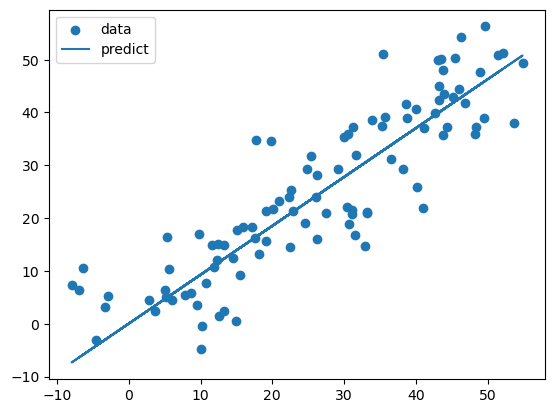

In [9]:
'''
    利用tensorflow自动微分求解简单线性回归的参数(w,b)

    载入库(导入相关包)、定义损失函数、定义预测值函数、定义训练函数、产生随机数作为数据集、训练模型(自动微分)
'''
#1.载入库
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

#2.定义损失函数
'''
'''
def loss(y,y_pred):
    return tf.reduce_mean(tf.square(y - y_pred)) #均方误差MSE= Σ(y-y_pred)^2 / n
# 3.定义预测值函数 y = w x + b

#初始值设为0
w = tf.Variable(0.0)
b = tf.Variable(0.0)

# 定义预测值函数
def predict(x):
    return w * x + b

#4.定义训练函数:在自动微分中需要重新计算损失函数值,assign_sub函数相当于 -= 操作
def train(X,y, epochs=40,lr=0.0001):
    current_loss = 0 #损失函数值
    for epoch in range(epochs): #执行训练周期
        with tf.GradientTape() as t: #自动微分
            t.watch(tf.constant(X)) #创建Tensorflow 常数参与自动微分
            current_loss = loss(y,predict(X)) #计算损失函数值
        dw,db = t.gradient(current_loss,[w,b]) #取得w,b的梯度
        #更新权重
        w.assign_sub(lr * dw) #w -= lr * dw
        b.assign_sub(lr * db)

        #显示每一训练周期的损失函数
        print(f'Epoch {epoch}:  Loss: {current_loss.numpy()}')
# 5.产生随机数作为数据集,进行测试
n = 100
X = np.linspace(0,50,n)
y = np.linspace(0,50,n)

#数据里面加一些噪音
X += np.random.uniform(-10,10,n)
y += np.random.uniform(-10,10,n)

#6.执行训练
train(X,y)

#w,b的最佳解
print(f'w:{w.numpy()} b:{b.numpy()}')

#7.绘图
plt.scatter(X,y,label='data')
plt.plot(X,predict(X),label='predict')
plt.legend()


In [8]:
'''
    利用tensorflow自动微分求解简单线性回归的参数(w,b)---->升级版本
    载入库(导入相关包)、定义损失函数、定义预测值函数、定义训练函数、产生随机数作为数据集、训练模型(自动微分)
'''
#1.导包
import tensorflow as tf
import numpy as np


#2.定义损失函数
def loss(y,y_pred):
    return tf.reduce_mean(tf.square(y - y_pred))

#定义预测函数
def predict(x):
    return w * x +b

#3.定义训练函数
def train(X,y,epochs = 200,lr = 0.01):
    for epoch in range(epochs):
        with tf.GradientTape() as t:
            #当前轮次的损失函数值
            curr_loss = loss(y,predict(X))
        dw,db = t.gradient(curr_loss,[w,b])

        #更新损失权重值
        w.assign_sub(lr * dw) #w -= lr * dw
        b.assign_sub(lr * db) #b -= lr * db

        if epoch % 20 == 0: #每20轮打印一次损失函数值
            print(f'Epoch {epoch}:  Loss: {curr_loss.numpy()}')

#4.产生随机数作为数据集,进行测试
true_w,true_b = 1.5,0.8 #假设真实参数
X = np.random.uniform(0,50,100) #随机数作为数据集
y = true_w * X + true_b + np.random.normal(0,5,100) #数据集加噪音

#开始训练
train(X,y)

#true_w,true_b
print(f'w:{w.numpy()} b:{b.numpy()}')


Epoch 0:  Loss: nan
Epoch 20:  Loss: nan
Epoch 40:  Loss: nan
Epoch 60:  Loss: nan
Epoch 80:  Loss: nan
Epoch 100:  Loss: nan
Epoch 120:  Loss: nan
Epoch 140:  Loss: nan
Epoch 160:  Loss: nan
Epoch 180:  Loss: nan
w:nan b:nan


E:\develop\anaconda3\envs\d2l_tensorflow\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


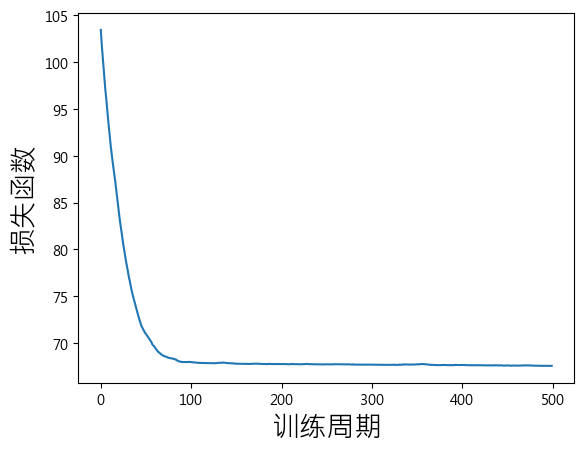

In [1]:
'''
    神经网络层

    上面实现了一条简单线性回归线的求解,神经网络是多条回归线的组合,并且每条回归线可能再乘上非线性的
    Activation Function,假如使用自动微分函数逐一定义每条公式,层层串连,程序可能需要很多个循环才能完成。所以为了
    简化程序开发的复杂度,TensorFlow/Keras直接构建了各式各样的神经层函数,可以使用神经层组合神经网络的结构,用户只需要专注算法的设计即可。神经网络由多个神经层组合而成，包括输入层(Input Layer)、隐藏层(Hidden Layer)及输出层(Output Layer)

    Tensorflow/Keras提供了数十种神经层,分成以下类别:
    1.核心类别层(Core Layer): 包括完全连接层(Full Connected Layer)、激励神经层(Activate Layer)、嵌入层(
    Embedding layer)等
    2.卷积层(Convalutional Layer)
    3.池化层(Pooling Layer)
    4.循环层(Recurrent Layer)
    5.前置处理层(Preprocessing layer): 提供One-Hot Encoding、影响前置处理、数据增补(Data Augmentation)
'''

#使用完全连接层估算简单线性回归的参数(w,b)

#1.产生随机数据
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

#产生随机数据100批
n = 100
x = np.linspace(0,50,n)
y = np.linspace(0,50,n)

#数据中加入一些噪音
x += np.random.uniform(-10,10,n)
y += np.random.uniform(-10,10,n)

#2.建立模型:神经网络仅使用一个完全连接层,而且输入只有一个神经元

#2.1定义完全连接层(dense)
layer1 = tf.keras.layers.Dense(units=1,input_shape=[1]) #units=1表示输出神经元个数,input_shape表示输入神经元个数

#2.2神经网络包含一个完全连接层
model = tf.keras.Sequential([layer1])

#3.定义模型的损失函数和优化器
model.compile(loss='mean_squared_error',optimizer=tf.keras.optimizers.Adam()) #损失函数为MSE(均方误差)、优化器为Adam

#4.模型训练,调用model.fit(x,y)后,训练过程的损失函数变化都会存到history中
history = model.fit(x,y,epochs=500,verbose=False)

#5.训练过程绘图
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

plt.xlabel('训练周期',fontsize=20)
plt.ylabel('损失函数',fontsize=20)
plt.plot(history.history['loss'])


# #6.取得模型参数w为第一层的第一个参数,b为输出层的第一个参数
#
# w = layer1.get_weights()[0][0][0]
# b = layer1.get_weights()[1][0]
#
# print(f'w:{w:.f} b:{b:.f}')
#
# #7.绘图显示回归线
#
# plt.scatter(x,y,label='data')
# plt.plot(x,x * w +b,label='predict')
# plt.legend()


-50.00 摄氏度 = -58.00 华氏度
-49.00 摄氏度 = -56.20 华氏度
-48.00 摄氏度 = -54.40 华氏度
-47.00 摄氏度 = -52.60 华氏度
-46.00 摄氏度 = -50.80 华氏度
-45.00 摄氏度 = -49.00 华氏度
-44.00 摄氏度 = -47.20 华氏度
-43.00 摄氏度 = -45.40 华氏度
-42.00 摄氏度 = -43.60 华氏度
-41.00 摄氏度 = -41.80 华氏度
-40.00 摄氏度 = -40.00 华氏度
-39.00 摄氏度 = -38.20 华氏度
-38.00 摄氏度 = -36.40 华氏度
-37.00 摄氏度 = -34.60 华氏度
-36.00 摄氏度 = -32.80 华氏度
-35.00 摄氏度 = -31.00 华氏度
-34.00 摄氏度 = -29.20 华氏度
-33.00 摄氏度 = -27.40 华氏度
-32.00 摄氏度 = -25.60 华氏度
-31.00 摄氏度 = -23.80 华氏度
-30.00 摄氏度 = -22.00 华氏度
-29.00 摄氏度 = -20.20 华氏度
-28.00 摄氏度 = -18.40 华氏度
-27.00 摄氏度 = -16.60 华氏度
-26.00 摄氏度 = -14.80 华氏度
-25.00 摄氏度 = -13.00 华氏度
-24.00 摄氏度 = -11.20 华氏度
-23.00 摄氏度 = -9.40 华氏度
-22.00 摄氏度 = -7.60 华氏度
-21.00 摄氏度 = -5.80 华氏度
-20.00 摄氏度 = -4.00 华氏度
-19.00 摄氏度 = -2.20 华氏度
-18.00 摄氏度 = -0.40 华氏度
-17.00 摄氏度 = 1.40 华氏度
-16.00 摄氏度 = 3.20 华氏度
-15.00 摄氏度 = 5.00 华氏度
-14.00 摄氏度 = 6.80 华氏度
-13.00 摄氏度 = 8.60 华氏度
-12.00 摄氏度 = 10.40 华氏度
-11.00 摄氏度 = 12.20 华氏度
-10.00 摄氏度 = 14.00 华氏度
-9.00 摄氏度 = 15.80 华氏度
-8.00 摄氏度 = 1

ValueError: Unrecognized data type: x=[100.0] (of type <class 'list'>)

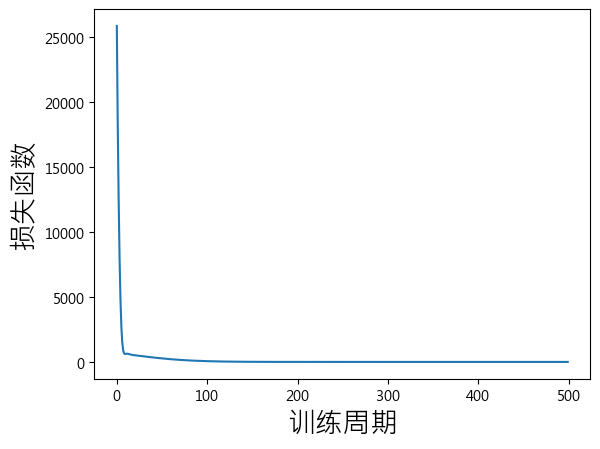

In [19]:
'''
    使用完全连接层推算华氏温度与摄氏温度的换算公式
    华氏(F)= 摄氏(C) * (9/5) + 32
'''

import numpy as np
import tensorflow as tf

#随机产生151个数据
n = 151
c = np.linspace(-50,100,n)
f = c * (9/5) + 32

for i, x in enumerate(c):
    print(f'{x:.2f} 摄氏度 = {f[i]:.2f} 华氏度')

#2.建立模型

#2.1定义完全连接层
layer1 = tf.keras.layers.Dense(units=1,input_shape=[1]) #units=1表示输出神经元个数,input_shape表示输入神经元个数
#2.2神经网络包含一层完全连接层
model = tf.keras.Sequential([layer1])
#3.定义模型的损失函数和优化器
model.compile(loss='mean_squared_error',optimizer=tf.keras.optimizers.Adam(0.1))

#4.模型训练,调用model.fit(x,y)后,训练过程的损失函数变化都会存到history中
history = model.fit(c,f,epochs=500,verbose=False)

#5.训练过程绘图
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False
plt.xlabel('训练周期',fontsize=20)
plt.ylabel('损失函数',fontsize=20)
plt.plot(history.history['loss'])

#5.测试 输入测试100度及0度转为华氏温度
y_pred = model.predict([100.0])[0][0]
print(f'100度 = {y_pred:.2f} 华氏度')
y_pred = model.predict([0.0])[0][0]
print(f'0度 = {y_pred:.2f} 华氏度')

#6.取得模型参数w、b
w = layer1.get_weights()[0][0][0]
b = layer1.get_weights()[1][0]

print(f'w:{w:.f} b:{b:.f}')
